In [ ]:

import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams, rcParamsDefault
from src.core.utils import  plot_tracks

rcParams.update(rcParamsDefault)
rcParams['pdf.fonttype'] = 42
sns.set(context = 'paper' , style='ticks' , 
    rc = {
        'figure.autolayout' : True,
        'font.sans-serif': ['Arial', 'Helvetica'],  # Specify Arial or Helvetica
        'axes.titlesize' : 6 ,
        'axes.titleweight' :'regular',
        
        'figure.titleweight' : 'regular' ,
        'figure.titlesize' : 6 ,
        'figure.labelsize' : 6 ,
        'figure.labelweight' : 'regular' , 
        
        'axes.labelsize' : 6 ,
        'axes.labelpad' : 2 ,
        'axes.labelweight' : 'regular' , 
        'axes.spines.top' : False,
        'axes.spines.right' : False,
        
        'legend.fontsize' : 6 ,
        'figure.figsize' : (8/2.54, 8/2.54) , 
        'figure.dpi': 300,      
        'figure.facecolor': 'w',
        'figure.edgecolor': 'black',   
        'legend.edgecolor': 'black',
        'legend.labelcolor': 'black',  # 设置图例标签字体颜色（在新版matplotlib中支持）
        'axes.edgecolor': 'black',
        'axes.labelcolor': 'black',
        'xtick.color': 'black',
        'ytick.color': 'black',
        'axes.titlecolor': 'black',
        'axes.labelcolor': 'black',

        'xtick.labelsize': 6,
        'ytick.labelsize': 6,
        'xtick.direction' : 'out' ,
        'ytick.direction' : 'out' ,
        'xtick.major.width': 0.5,  # X轴刻度主刻度线宽度
        'ytick.major.width': 0.5, 
        'xtick.major.size' : 2 ,
        'ytick.major.size' : 2 ,
        'xtick.minor.size': 2,  # X-axis minor tick length
        'ytick.minor.size': 2,  # Y-axis minor tick length

        'xtick.major.pad' : 2,
        'ytick.major.pad' : 2,
        'text.color': 'black',  # 全局文字颜色

        'lines.linewidth' : 0.75  , 
        'axes.linewidth': 0.5,  # Axis line width
        'savefig.dpi': 300,  # Save resolution 
        'savefig.bbox': 'tight',  # Tight bounding box       
        }
    )

sns.set_palette("colorblind")
MARKS = ["H3K4me1","H3K4me3","H3K9me3","H3K27me3","H3K36me3","H3K27ac","H3K9ac"]



## ENSG00000143294

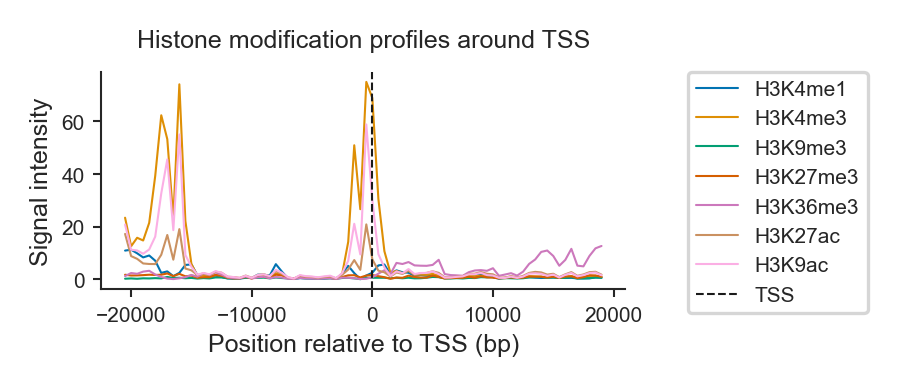

In [14]:
tracks = np.load('binned_npys/ENSG00000143294.npy')  # (80, 7)
plot_tracks(tracks)

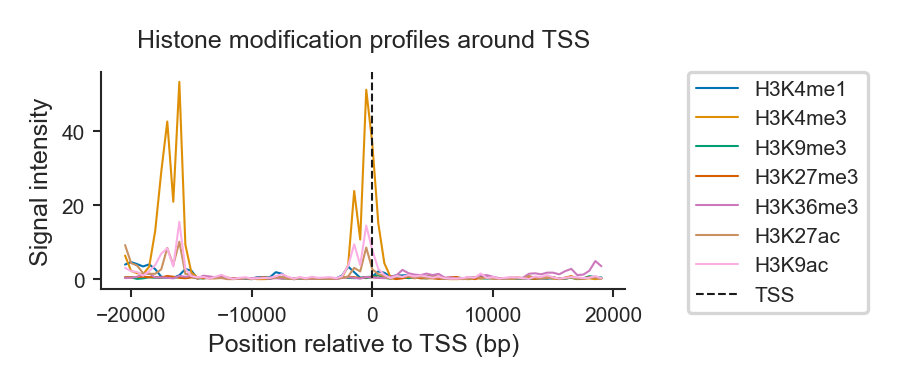

In [15]:
tracks = np.load('data/ENSG00000143294.npy').T # (80, 7)
plot_tracks(tracks)

## ENSG00000143340

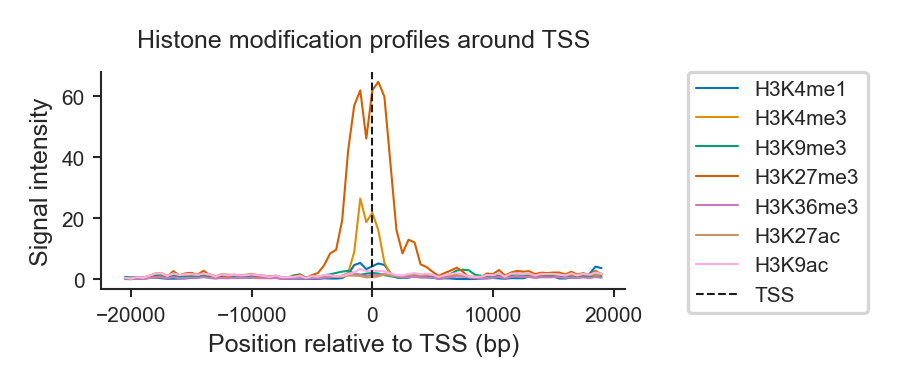

In [7]:
tracks = np.load('outputs/E003_enformer_prediction/regions/ENSG00000143340.npy') # (80, 7)
plot_tracks(tracks)

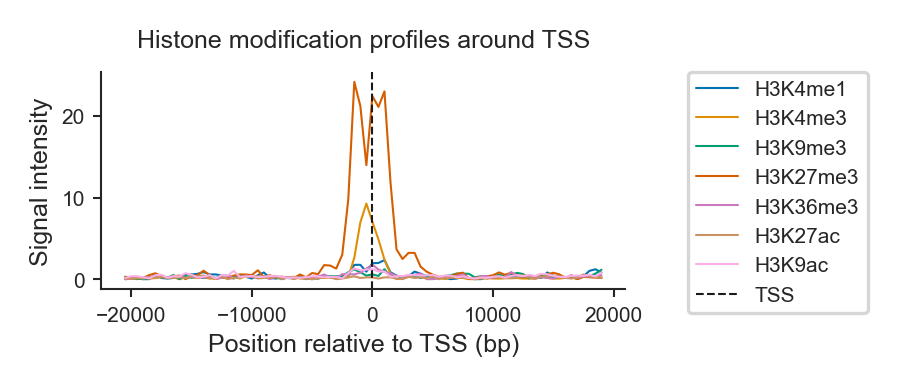

In [8]:
tracks = np.load('data/ENSG00000143340.npy').T # (80, 7)
plot_tracks(tracks)

## ENSG00000067048

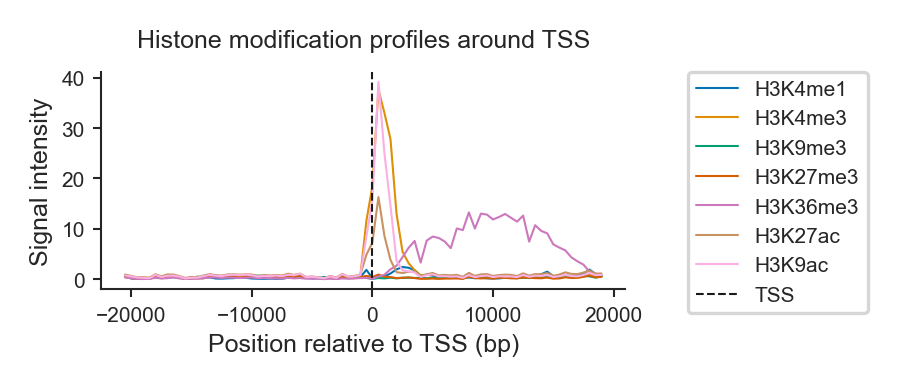

In [23]:
tracks = np.load('binned_npys/ENSG00000067048.npy')/2 # (80, 7)
plot_tracks(tracks)

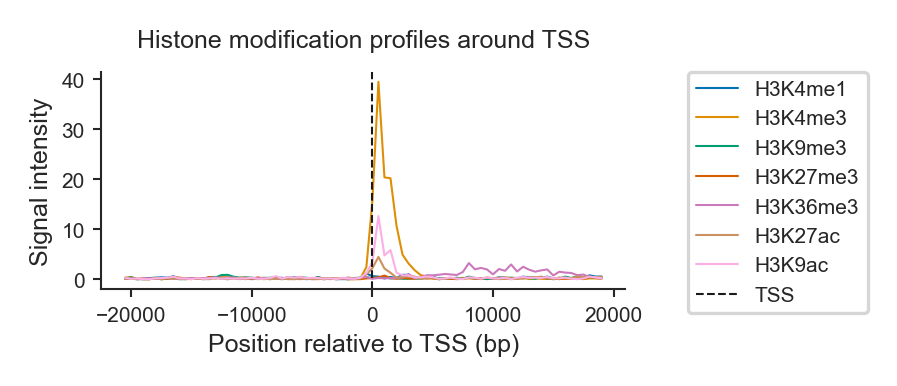

In [19]:
tracks = np.load('data/ENSG00000067048.npy').T # (80, 7)
plot_tracks(tracks)

## ENSG00000198692

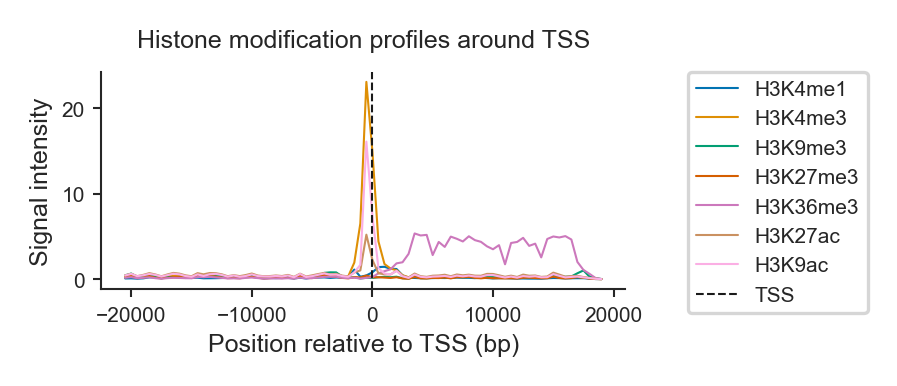

In [22]:
tracks = np.load('binned_npys/ENSG00000198692.npy') # (80, 7)
tracks = tracks/3
plot_tracks(tracks)

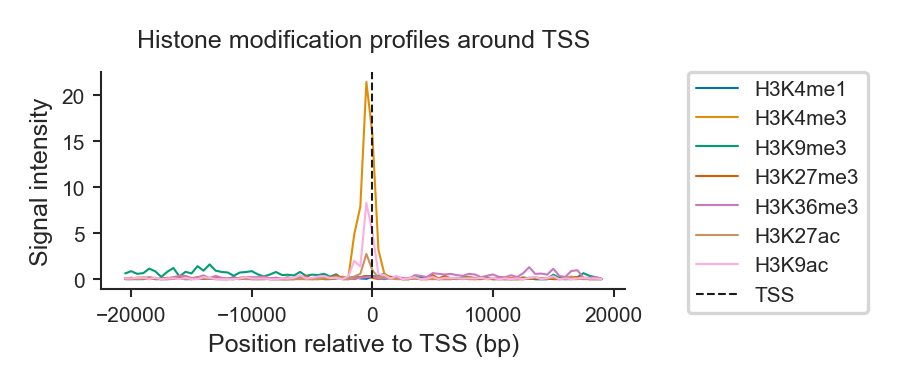

In [21]:
tracks = np.load('data/ENSG00000198692.npy').T # (80, 7)
plot_tracks(tracks)

## Test

In [21]:
import random
import gzip
from src.utils import FastaStringExtractor
import kipoiseq

# ================= 基础配置 =================
fasta_file = './extra/hg19.fa'
fasta_extractor = FastaStringExtractor(fasta_file)

chrom = 'chr1'
start = 156717325
end = 156757325
strand = '+'
interval = kipoiseq.Interval(chrom, start, end, strand=strand)
target_seq = fasta_extractor.extract(interval)

replaced_length = 1000
num_samples = 100   # 这里改成 100k
output_path = "random_center_replaced_100k.fa.gz"

# ================= 工具函数 =================
def random_dna(length: int, alphabet="ACGT") -> str:
    """Generate a random DNA string of given length."""
    return "".join(random.choices(alphabet, k=length))

def random_replace_center_seq(target_seq: str, replaced_length: int) -> str:
    """Replace the center segment of target_seq with a random DNA string."""
    total_length = len(target_seq)
    random_seq = random_dna(length=replaced_length)
    left = (total_length - replaced_length) // 2
    right = total_length - left - replaced_length
    return target_seq[:left] + random_seq + target_seq[-right:]

def make_ids(num_samples: int, prefix: str = "ENSGRND"):
    """Generate IDs like ENSGRND00000001."""
    width = max(8, len(str(num_samples)))
    for i in range(1, num_samples + 1):
        yield f"{prefix}{i:0{width}d}"

def save_fasta_gz(sequences, ids, output_path, line_width=80):
    """Save sequences to a gzipped FASTA file."""
    with gzip.open(output_path, "wt") as f:
        for seq_id, seq in zip(ids, sequences):
            f.write(f">{seq_id}\n")
            for i in range(0, len(seq), line_width):
                f.write(seq[i:i+line_width] + "\n")

# ================= 主流程 =================
if __name__ == "__main__":
    sequences = [random_replace_center_seq(target_seq, replaced_length) for _ in range(num_samples)]
    ids = list(make_ids(num_samples))
    save_fasta_gz(sequences, ids, output_path)
    print(f"Saved {num_samples} sequences to {output_path}")

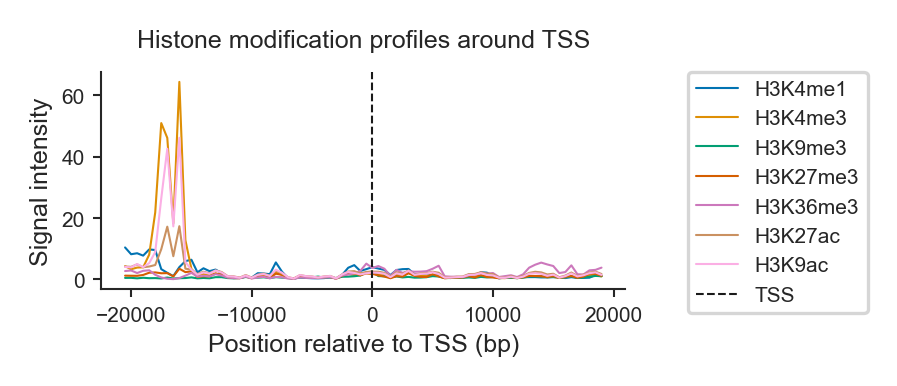

In [3]:
tracks = np.load('outputs/random_center_replaced/regions/ENSGRND00000068.npy') # (80, 7)
plot_tracks(tracks)

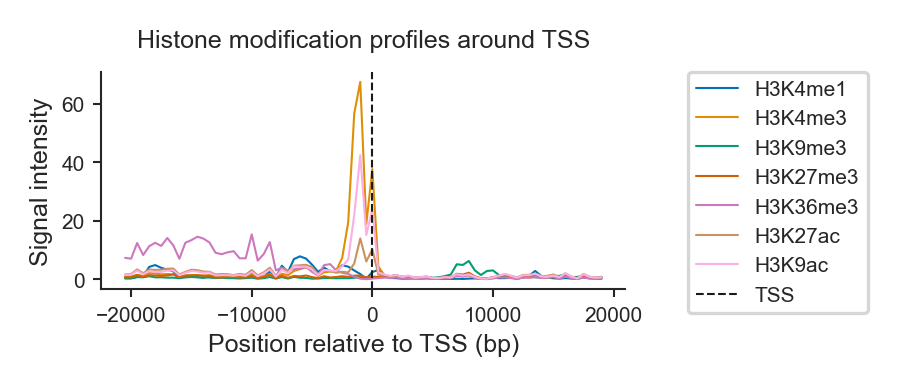

In [20]:
tracks = np.load('outputs/E003_enformer_prediction/regions/ENSG00000155660.npy') # (80, 7)
plot_tracks(tracks)

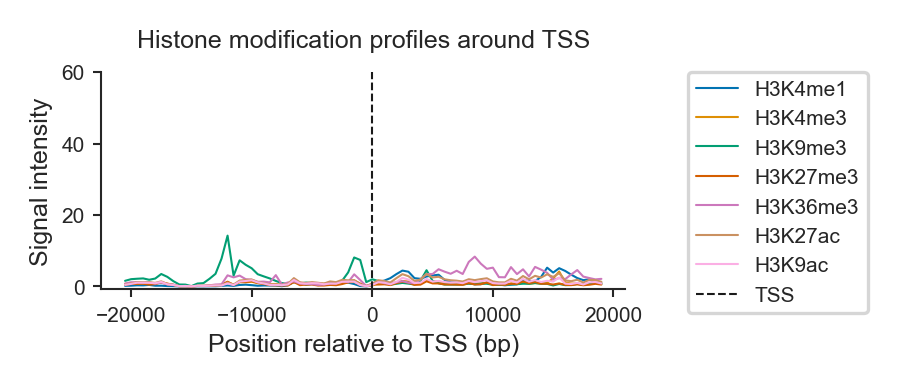

In [18]:
tracks = np.load('outputs/ENSG00000155660_random_center_replaced_100k/regions/ENSGRND00000021.npy') # (80, 7)
plot_tracks(tracks,ylim=60)